# Supermarket Sales Forecasting — Model Selection
## Phase 4: Model Training & Baseline Comparison
**Author:** R M Hamdhan  
**Batch:** HNDSE 25.1F | Kandy NIBM  
**Input:** X_train, X_test, y_train, y_test (from Phase 3)  
**Goal:** Train 3 algorithms, compare baseline performance, select best model

In [1]:
# ── IMPORTS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# ML algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Data and Pipeline Objects
Loading preprocessed data from Phase 3

In [2]:
# ── LOAD PREPROCESSED DATA ───────────────────────────────
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# Load saved pipeline objects
with open('../model/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../model/encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

print("✓ Data loaded successfully")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape} | Min: {y_train.min():.2f} | Max: {y_train.max():.2f}")
print(f"  y_test  : {y_test.shape}  | Min: {y_test.min():.2f} | Max: {y_test.max():.2f}")
print(f"\nFeatures used:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2}. {col}")

✓ Data loaded successfully
  X_train : (800, 14)
  X_test  : (200, 14)
  y_train : (800,) | Min: 0.58 | Max: 874.98
  y_test  : (200,)  | Min: 0.48 | Max: 846.30

Features used:
   1. Branch
   2. Customer type
   3. Gender
   4. Product line
   5. Unit price
   6. Quantity
   7. Total
   8. Payment
   9. Rating
  10. hour
  11. is_weekend
  12. day_num
  13. month_num
  14. price_quantity


## 2. Evaluation Helper Function
A reusable function to calculate and display all metrics

In [3]:
# ── EVALUATION FUNCTION ───────────────────────────────────
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    mae_test   = mean_absolute_error(y_test, y_pred_test)
    r2_test    = r2_score(y_test, y_pred_test)
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  RMSE (train) : {rmse_train:.4f}")
    print(f"  RMSE (test)  : {rmse_test:.4f}")
    print(f"  MAE  (test)  : {mae_test:.4f}")
    print(f"  R²   (test)  : {r2_test:.4f}")
    
    # Overfitting check
    if rmse_train < rmse_test * 0.8:
        print(f"  ⚠️  Possible overfitting detected")
    else:
        print(f"  ✓  No significant overfitting")
    
    return {
        'Model'      : name,
        'RMSE_train' : round(rmse_train, 4),
        'RMSE_test'  : round(rmse_test,  4),
        'MAE_test'   : round(mae_test,   4),
        'R2_test'    : round(r2_test,    4),
        'y_pred'     : y_pred_test
    }

print("✓ Evaluation function defined")

✓ Evaluation function defined


## 3. Model 1 — Linear Regression (Baseline)
Simplest model — fits a straight line through the data

In [4]:
# ── MODEL 1: LINEAR REGRESSION ───────────────────────────
# Linear Regression finds the best linear combination of features
# Formula: gross_income = w1*Branch + w2*Quantity + w3*Total + ... + bias
# Simple, fast, interpretable — used as our baseline

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("✓ Linear Regression trained")
print(f"\nModel coefficients (feature weights):")
for feat, coef in zip(X_train.columns, lr_model.coef_):
    print(f"  {feat:20s}: {coef:+.4f}")
print(f"\nBias (intercept): {lr_model.intercept_:.4f}")

# Evaluate
lr_results = evaluate_model(
    "Linear Regression", lr_model,
    X_train, X_test, y_train, y_test
)

✓ Linear Regression trained

Model coefficients (feature weights):
  Branch              : +12.0366
  Customer type       : -42.4620
  Gender              : +0.7423
  Product line        : -0.2952
  Unit price          : -26.8015
  Quantity            : -13.1613
  Total               : +72.2500
  Payment             : -0.3929
  Rating              : +2.9910
  hour                : +1.5699
  is_weekend          : +2.0012
  day_num             : +0.3165
  month_num           : +1.9651
  price_quantity      : +72.2500

Bias (intercept): 120.1684

  Linear Regression
  RMSE (train) : 57.7138
  RMSE (test)  : 54.4609
  MAE  (test)  : 42.1347
  R²   (test)  : 0.8333
  ✓  No significant overfitting


## 4. Model 2 — Random Forest Regressor
Ensemble of decision trees — handles non-linear relationships

In [5]:
# ── MODEL 2: RANDOM FOREST ───────────────────────────────
# Builds 100 decision trees on random subsets of data/features
# Final prediction = average of all 100 tree predictions
# More powerful than Linear Regression for complex patterns

rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=10,       # maximum depth of each tree
    random_state=42,    # ensures same results every run
    n_jobs=-1           # use all CPU cores for speed
)
rf_model.fit(X_train, y_train)

print("✓ Random Forest trained")
print(f"  Trees built : {rf_model.n_estimators}")
print(f"  Max depth   : {rf_model.max_depth}")

# Feature importance
feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importances:")
for _, row in feat_imp.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f} {bar}")

# Evaluate
rf_results = evaluate_model(
    "Random Forest", rf_model,
    X_train, X_test, y_train, y_test
)

✓ Random Forest trained
  Trees built : 100
  Max depth   : 10

Feature Importances:
  price_quantity      : 0.4201 █████████████████████
  Total               : 0.3718 ██████████████████
  Customer type       : 0.0948 ████
  Branch              : 0.0645 ███
  Quantity            : 0.0391 █
  Unit price          : 0.0025 
  month_num           : 0.0015 
  day_num             : 0.0013 
  hour                : 0.0013 
  Rating              : 0.0013 
  Product line        : 0.0007 
  Gender              : 0.0004 
  Payment             : 0.0004 
  is_weekend          : 0.0001 

  Random Forest
  RMSE (train) : 7.3765
  RMSE (test)  : 15.8673
  MAE  (test)  : 7.7760
  R²   (test)  : 0.9859
  ⚠️  Possible overfitting detected


## 5. Model 3 — XGBoost Regressor
Gradient boosting — sequential trees each fixing previous errors

In [6]:
# ── MODEL 3: XGBOOST ─────────────────────────────────────
# Builds trees sequentially — each tree corrects errors of previous
# Uses gradient descent to minimize loss function
# State-of-the-art for tabular data forecasting

xgb_model = XGBRegressor(
    n_estimators=100,     # number of boosting rounds
    max_depth=6,          # maximum tree depth
    learning_rate=0.1,    # how much each tree contributes
    subsample=0.8,        # fraction of rows used per tree
    colsample_bytree=0.8, # fraction of features used per tree
    random_state=42,
    verbosity=0           # suppress training output
)
xgb_model.fit(X_train, y_train)

print("✓ XGBoost trained")
print(f"  Boosting rounds : {xgb_model.n_estimators}")
print(f"  Learning rate   : {xgb_model.learning_rate}")
print(f"  Max depth       : {xgb_model.max_depth}")

# Feature importance
xgb_feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importances:")
for _, row in xgb_feat_imp.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f} {bar}")

# Evaluate
xgb_results = evaluate_model(
    "XGBoost", xgb_model,
    X_train, X_test, y_train, y_test
)

✓ XGBoost trained
  Boosting rounds : 100
  Learning rate   : 0.1
  Max depth       : 6

Feature Importances:
  price_quantity      : 0.5597 ███████████████████████████
  Total               : 0.2082 ██████████
  Customer type       : 0.1447 ███████
  Branch              : 0.0344 █
  Quantity            : 0.0303 █
  Unit price          : 0.0141 
  month_num           : 0.0022 
  Rating              : 0.0020 
  Product line        : 0.0011 
  day_num             : 0.0010 
  Payment             : 0.0009 
  hour                : 0.0008 
  Gender              : 0.0004 
  is_weekend          : 0.0004 

  XGBoost
  RMSE (train) : 2.4113
  RMSE (test)  : 10.5496
  MAE  (test)  : 6.8586
  R²   (test)  : 0.9937
  ⚠️  Possible overfitting detected


## 6. Model Comparison
Comparing all three models side by side

In [7]:
# ── COMPARISON TABLE ─────────────────────────────────────
results_df = pd.DataFrame([
    {k: v for k, v in lr_results.items()  if k != 'y_pred'},
    {k: v for k, v in rf_results.items()  if k != 'y_pred'},
    {k: v for k, v in xgb_results.items() if k != 'y_pred'},
])

print("=" * 65)
print("  BASELINE MODEL COMPARISON")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)
print(f"\n✓ Best RMSE : {results_df.loc[results_df['RMSE_test'].idxmin(), 'Model']}")
print(f"✓ Best MAE  : {results_df.loc[results_df['MAE_test'].idxmin(),  'Model']}")
print(f"✓ Best R²   : {results_df.loc[results_df['R2_test'].idxmax(),   'Model']}")
print(f"\n→ Selected for Phase 5 tuning: XGBoost")

  BASELINE MODEL COMPARISON
            Model  RMSE_train  RMSE_test  MAE_test  R2_test
Linear Regression     57.7138    54.4609   42.1347   0.8333
    Random Forest      7.3765    15.8673    7.7760   0.9859
          XGBoost      2.4113    10.5496    6.8586   0.9937

✓ Best RMSE : XGBoost
✓ Best MAE  : XGBoost
✓ Best R²   : XGBoost

→ Selected for Phase 5 tuning: XGBoost


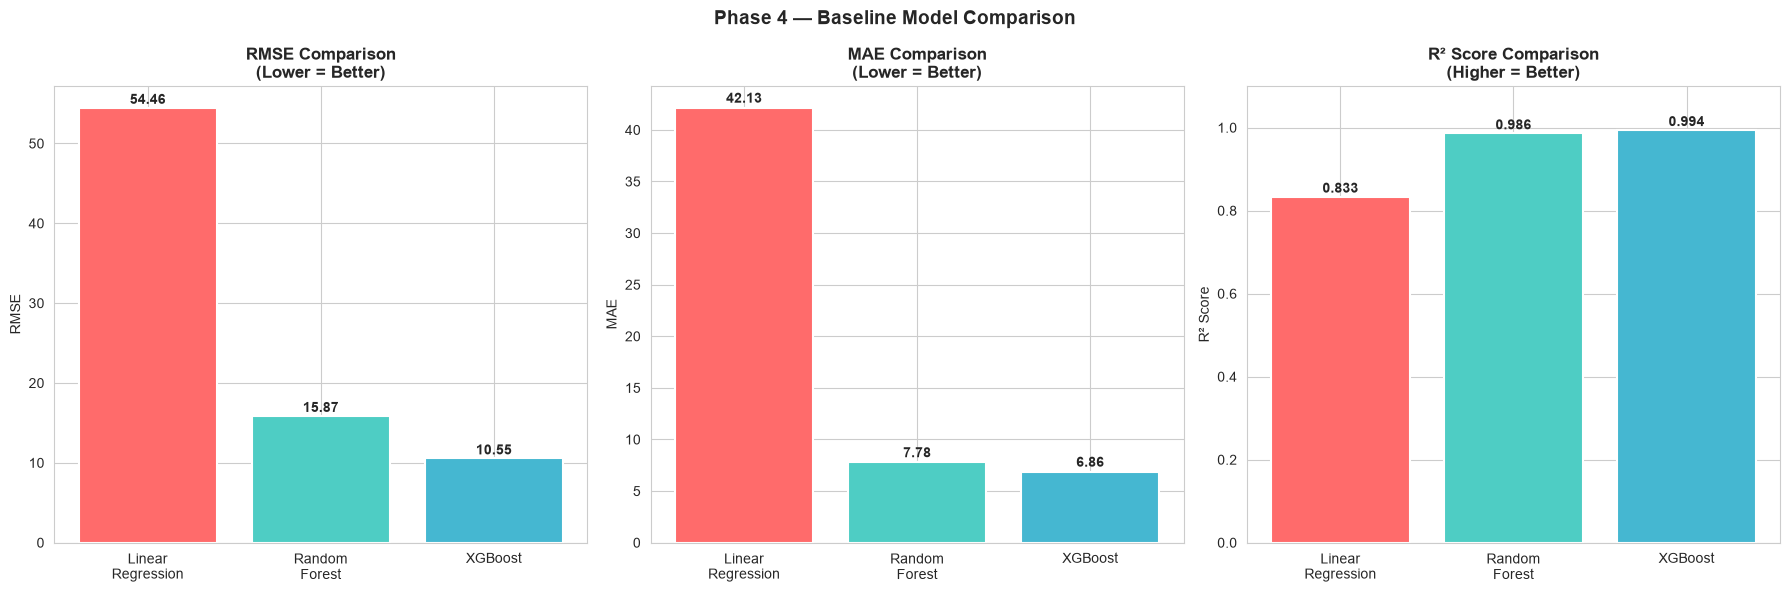

In [8]:
# ── COMPARISON CHARTS ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models    = ['Linear\nRegression', 'Random\nForest', 'XGBoost']
rmse_vals = [lr_results['RMSE_test'], rf_results['RMSE_test'], xgb_results['RMSE_test']]
mae_vals  = [lr_results['MAE_test'],  rf_results['MAE_test'],  xgb_results['MAE_test']]
r2_vals   = [lr_results['R2_test'],   rf_results['R2_test'],   xgb_results['R2_test']]
colors    = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Chart 1 — RMSE comparison (lower is better)
bars = axes[0].bar(models, rmse_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('RMSE Comparison\n(Lower = Better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', fontweight='bold')

# Chart 2 — MAE comparison (lower is better)
bars = axes[1].bar(models, mae_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('MAE Comparison\n(Lower = Better)', fontweight='bold')
axes[1].set_ylabel('MAE')
for bar, val in zip(bars, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', fontweight='bold')

# Chart 3 — R² comparison (higher is better)
bars = axes[2].bar(models, r2_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('R² Score Comparison\n(Higher = Better)', fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1.1)
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Phase 4 — Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

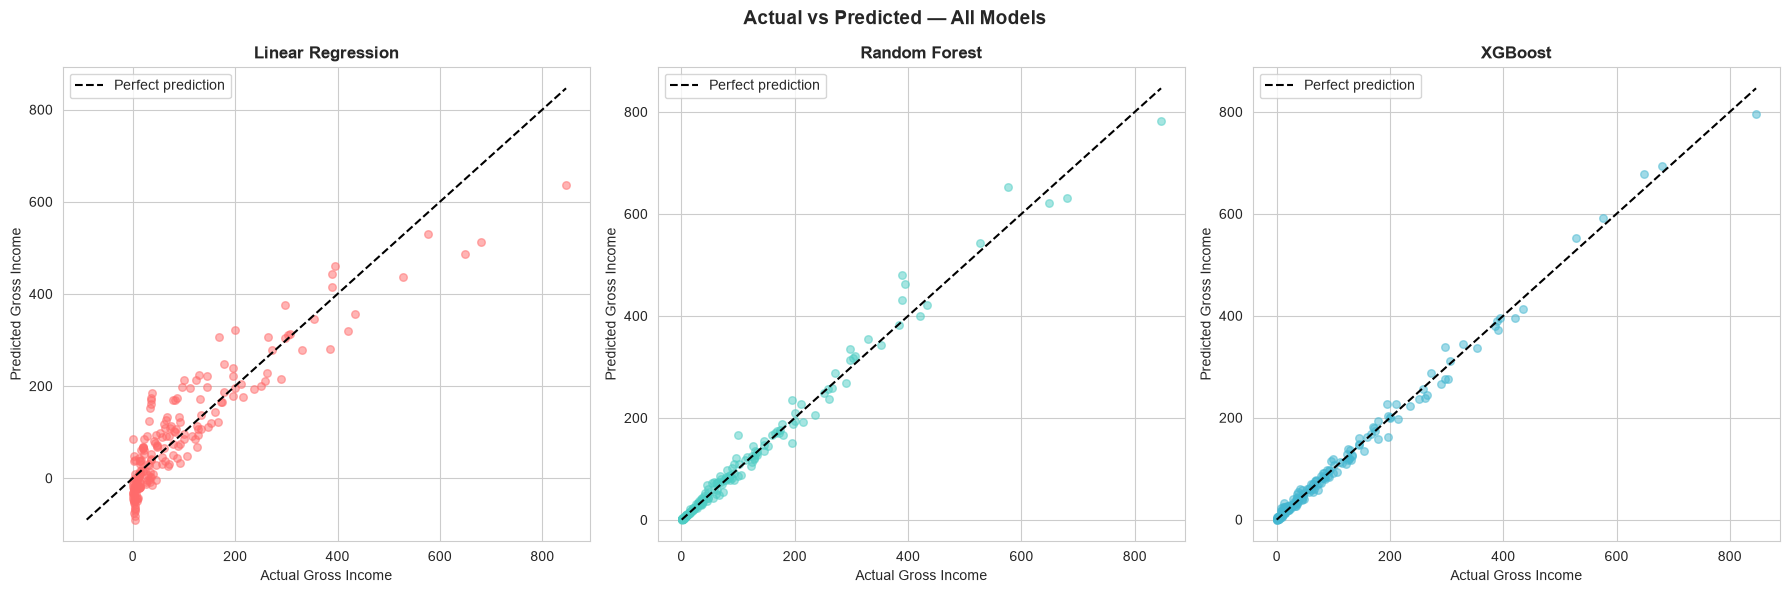

In [9]:
# ── ACTUAL VS PREDICTED PLOTS ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_results = [
    ('Linear Regression', lr_results['y_pred'],  '#FF6B6B'),
    ('Random Forest',     rf_results['y_pred'],  '#4ECDC4'),
    ('XGBoost',           xgb_results['y_pred'], '#45B7D1'),
]

for ax, (name, y_pred, color) in zip(axes, model_results):
    ax.scatter(y_test, y_pred, alpha=0.5, color=color, s=30)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='Perfect prediction')
    
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Actual Gross Income')
    ax.set_ylabel('Predicted Gross Income')
    ax.legend()

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── SAVE BEST MODEL ──────────────────────────────────────
# XGBoost selected as best model → proceed to Phase 5 tuning

with open('../model/xgb_baseline.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../model/rf_baseline.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../model/lr_baseline.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save comparison results
results_df.to_csv('../data/model_comparison.csv', index=False)

print("✓ All models saved:")
print("  ../model/xgb_baseline.pkl  — XGBoost (best model → Phase 5)")
print("  ../model/rf_baseline.pkl   — Random Forest")
print("  ../model/lr_baseline.pkl   — Linear Regression")
print("  ../data/model_comparison.csv — Comparison table")
print(f"\n✓ Phase 4 Complete!")
print(f"  → Proceeding to Phase 5: Hyperparameter Tuning of XGBoost")

✓ All models saved:
  ../model/xgb_baseline.pkl  — XGBoost (best model → Phase 5)
  ../model/rf_baseline.pkl   — Random Forest
  ../model/lr_baseline.pkl   — Linear Regression
  ../data/model_comparison.csv — Comparison table

✓ Phase 4 Complete!
  → Proceeding to Phase 5: Hyperparameter Tuning of XGBoost
